# Decision Tree

## Importación de librerías y paquetes y definición de constantes

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
# To save models
import json
import pickle
# Modelado
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
# Métricas
from utils import get_classifier_metrics
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV, cross_val_score
# Warnings
import warnings

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Vamos a probar tres enfoques diferentes para la generación de este modelo:

1. Dataset truncado
2. Dataset con valores nulos remplazados por la moda
3. Dataset con valores nulos remplazados por los k-nearest neighbors


## 1. Dataset truncado:

### Cargamos el dataset procedente del eda previo

In [3]:
df_filtrado = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_filtrado.csv")
df_filtrado

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,89,66,23,94,28.1,0.167,21,0
1,0,137,40,35,168,43.1,2.288,33,1
2,3,78,50,32,88,31.0,0.248,26,1
3,2,197,70,45,543,30.5,0.158,53,1
4,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
388,0,181,88,44,510,43.3,0.222,26,1
389,1,128,88,39,110,36.5,1.057,37,1
390,2,88,58,26,16,28.4,0.766,22,0
391,10,101,76,48,180,32.9,0.171,63,0


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [4]:
# Instancia de: from sklearn.model_selection import train_test_split
X_train_filtrado, X_test_filtrado, y_train_filtrado, y_test_filtrado = train_test_split(df_filtrado.drop('Outcome', axis=1), 
                                                                                        df_filtrado['Outcome'],
                                                                                        test_size=0.2,
                                                                                        random_state=24,
                                                                                        stratify=df_filtrado['Outcome'])
X_train_filtrado

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
282,5,187,76,27,207,43.6,1.034,53
39,7,81,78,40,48,46.7,0.261,42
295,4,154,72,29,126,31.3,0.338,37
341,3,80,82,31,70,34.2,1.292,27
51,8,155,62,26,495,34.0,0.543,46
...,...,...,...,...,...,...,...,...
364,2,93,64,32,160,38.0,0.674,23
265,9,145,88,34,165,30.3,0.771,53
232,0,91,68,32,210,39.9,0.381,25
315,3,106,54,21,158,30.9,0.292,24


#### Dibujamos la curva de validación para buscar la mejor profundidad del árbol

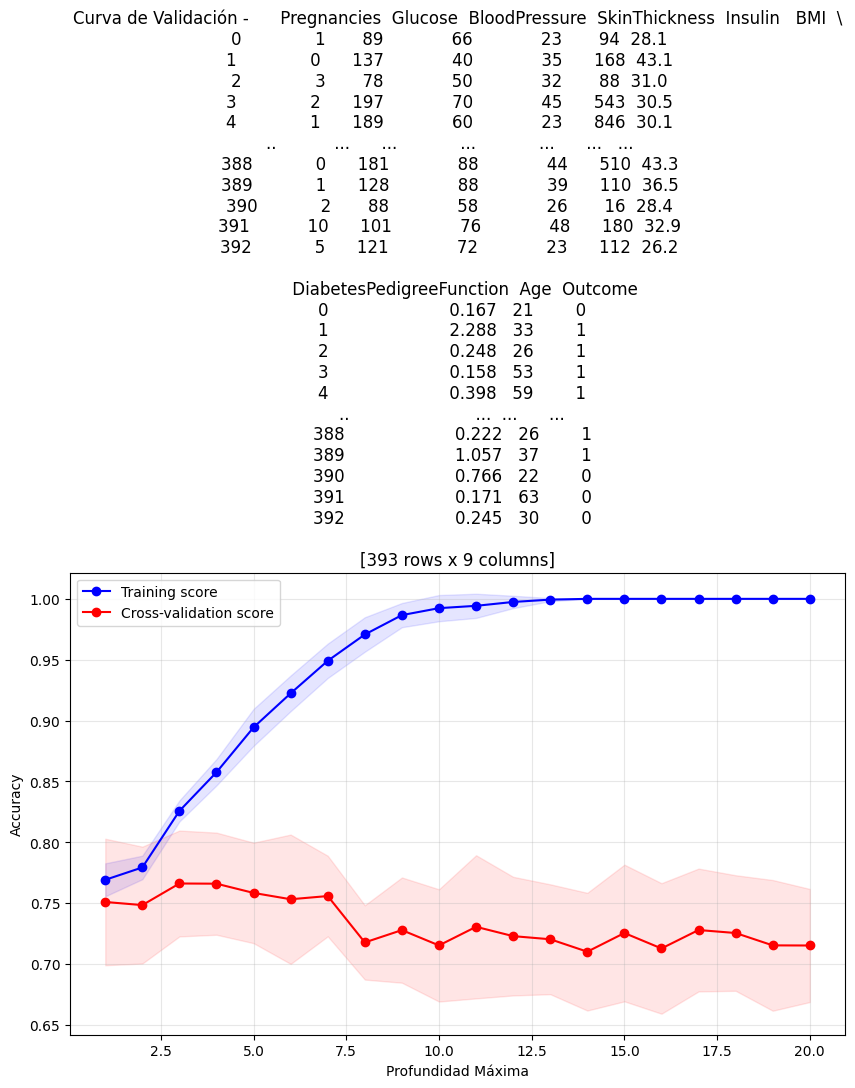

In [ ]:
param_range = range(1, 21)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(), df_filtrado.drop('Outcome', axis=1), df_filtrado['Outcome'], 
    param_name='max_depth',
    param_range=range(1, 21),
    cv=5  # 5-fold cross-validation
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, 'o-', color='blue', label='Training score')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')    
plt.plot(param_range, test_mean, 'o-', color='red', label='Cross-validation score')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, 
                     alpha=0.1, color='red')    
plt.xlabel('Profundidad Máxima')
plt.ylabel('Accuracy')
plt.title(f'Curva de Validación - {df_filtrado}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Modelado y Ajuste

In [6]:
dt_classifier_model = DecisionTreeClassifier(max_depth=4, random_state=24)
dt_classifier_model.fit(X_train_filtrado, y_train_filtrado)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

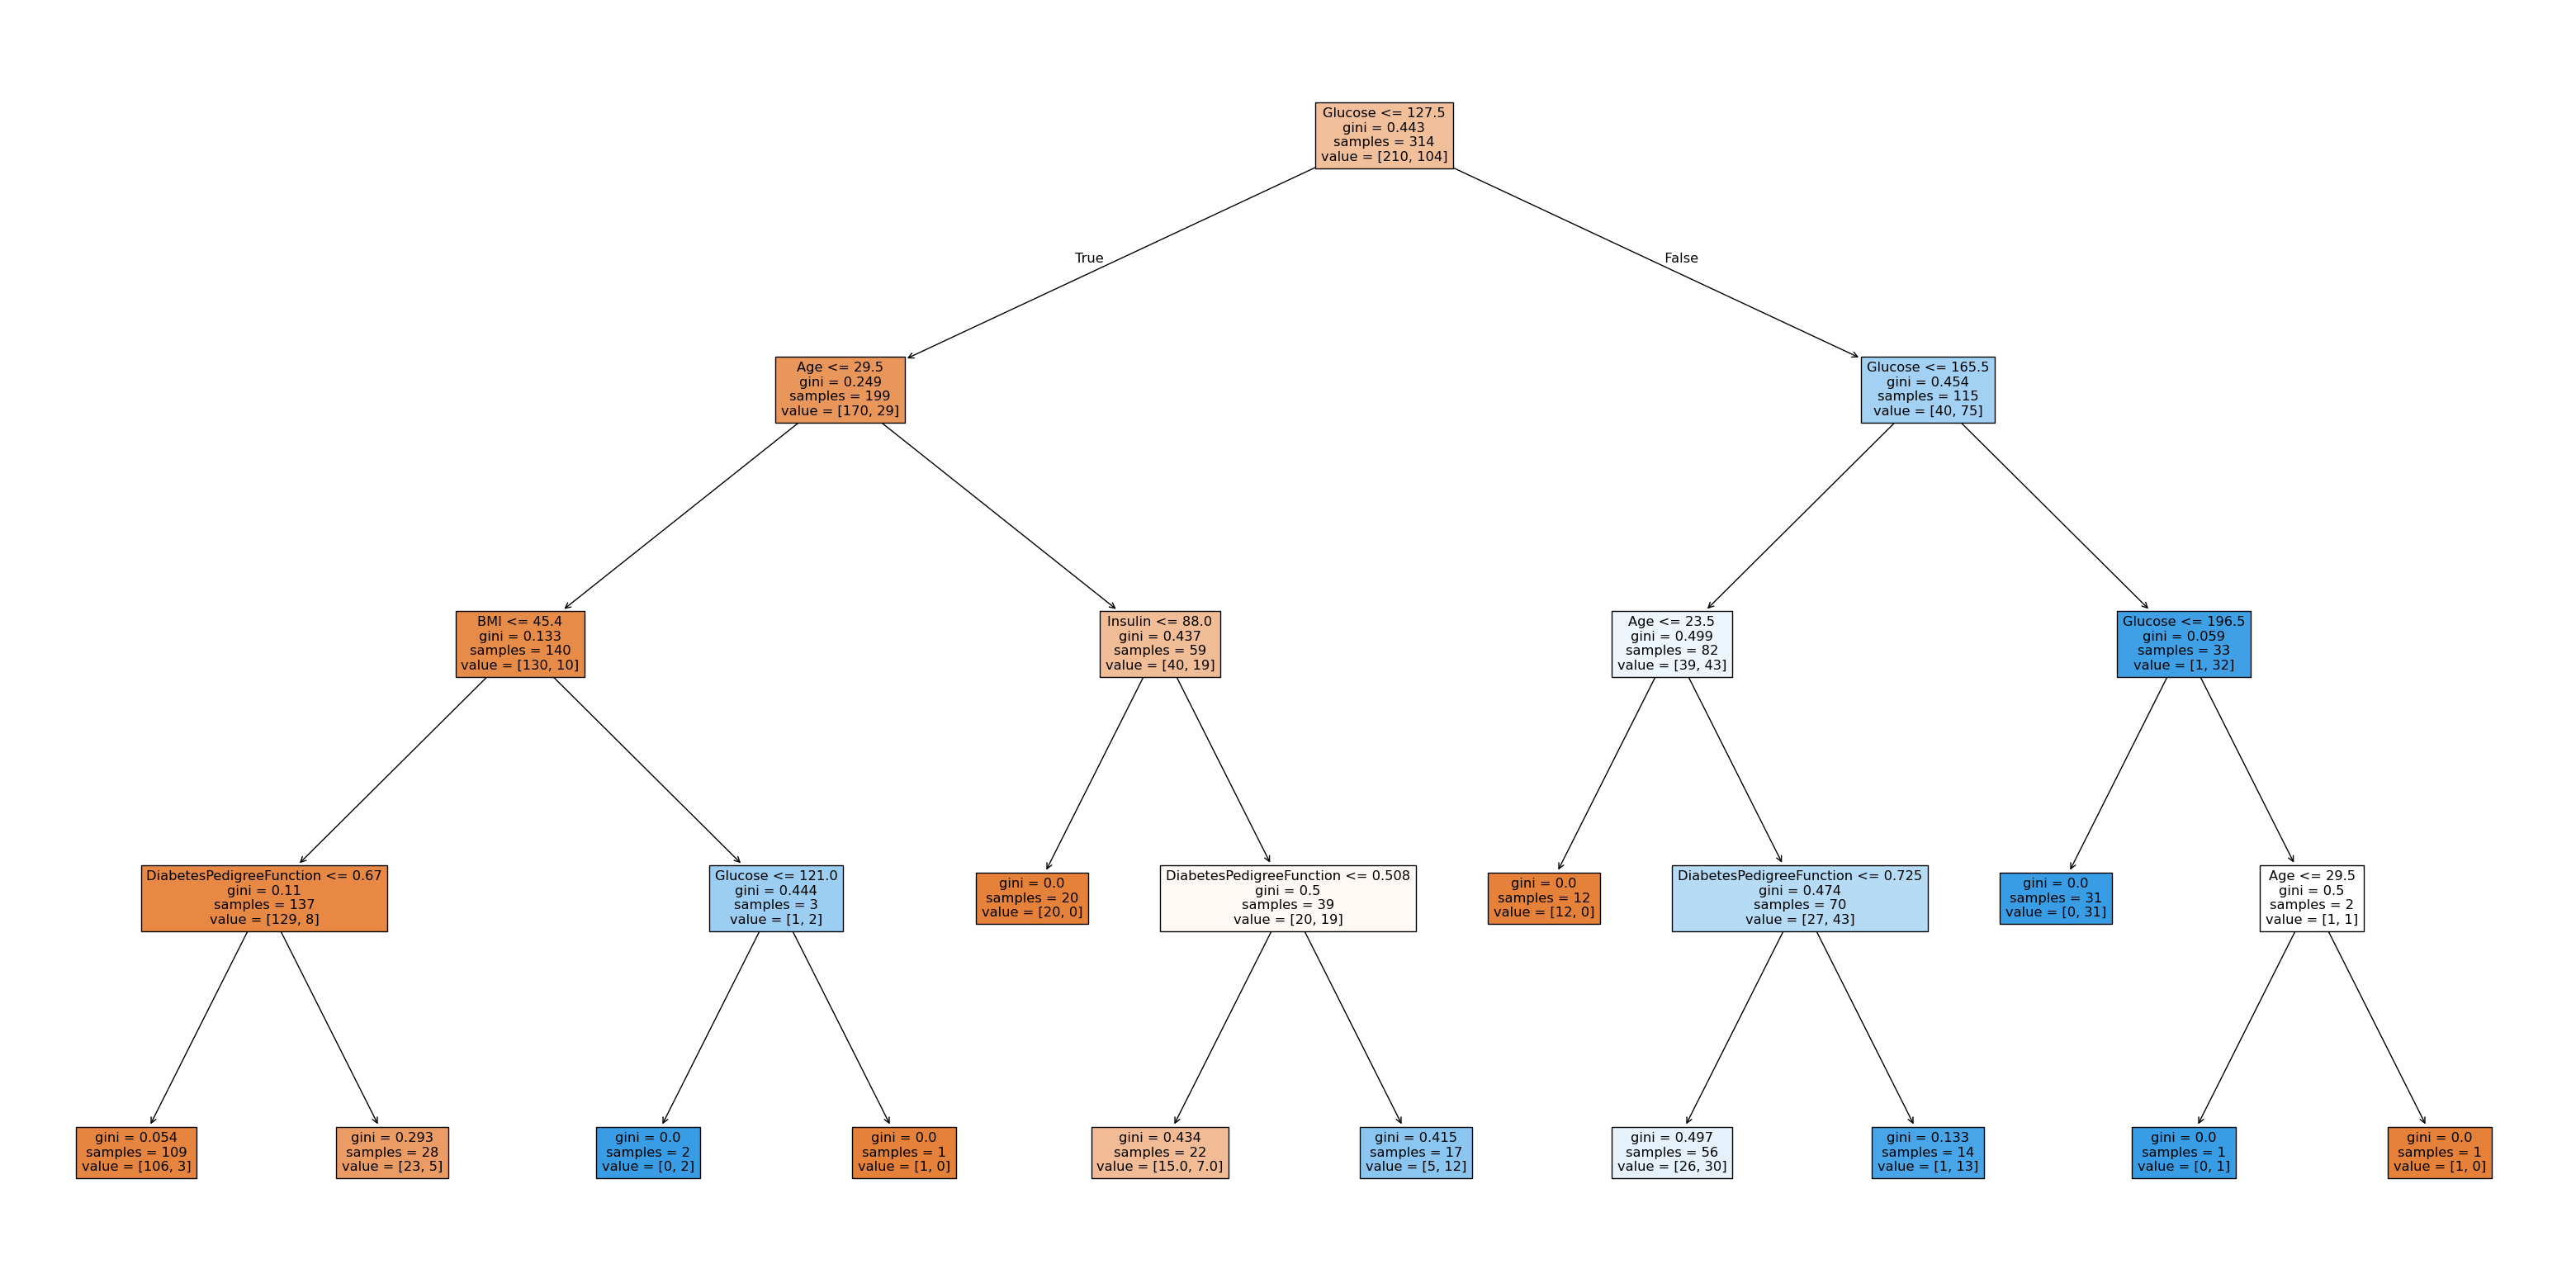

In [7]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train_filtrado.columns),
               filled=True)
plt.show()

#### Si no ajustamos la profundidad del árbol pueden haber gráficos que no podamos manejar con facilidad, a priori lo dejamos así para comparar despues de optimizar parámetros

#### Predicción 

In [8]:
y_pred_test_fil = dt_classifier_model.predict(X_test_filtrado)
y_pred_test_fil

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0])

In [9]:
y_pred_train_fil = dt_classifier_model.predict(X_train_filtrado)
y_pred_train_fil

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,

#### Métricas

In [10]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.850318,0.850318,0.850318,0.850318
Test set,0.759494,0.759494,0.759494,0.759494


In [11]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.850318,0.837243,0.828908,0.851694
Test set,0.759494,0.743023,0.737813,0.761974


In [12]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.850318,0.852816,0.860429,0.850318
Test set,0.759494,0.765258,0.782842,0.759494


#### Oservamos que cuanto menos profundidad tiene el árbol, las métricas de y-test son mejores pero las de y-train van empeorando y que las métricas en micro son las que mejor resultado dan

## 2. Dataset con valores nulos remplazados por la moda

In [13]:
df_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_mode.csv")
df_mode

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,105.0,33.6,0.627,50,1
1,1,85,66,29.0,105.0,26.6,0.351,31,0
2,8,183,64,32.0,105.0,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0
764,2,122,70,27.0,105.0,36.8,0.340,27,0
765,5,121,72,23.0,112.0,26.2,0.245,30,0
766,1,126,60,32.0,105.0,30.1,0.349,47,1


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [14]:
# Instancia de: from sklearn.model_selection import train_test_split
X_train_mode, X_test_mode, y_train_mode, y_test_mode = train_test_split(df_mode.drop('Outcome', axis=1), 
                                                                        df_mode['Outcome'],
                                                                        test_size=0.2,
                                                                        random_state=24,
                                                                        stratify=df_mode['Outcome'])
X_train_mode

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
712,10,129,62,36.0,105.0,41.2,0.441,38
626,0,125,68,32.0,105.0,24.7,0.206,21
157,1,109,56,21.0,135.0,25.2,0.833,23
401,6,137,61,32.0,105.0,24.2,0.151,55
355,9,165,88,32.0,105.0,30.4,0.302,49
...,...,...,...,...,...,...,...,...
381,0,105,68,22.0,105.0,20.0,0.236,22
324,2,112,75,32.0,105.0,35.7,0.148,21
68,1,95,66,13.0,38.0,19.6,0.334,25
704,4,110,76,20.0,100.0,28.4,0.118,27


#### Dibujamos la curva de validación para buscar la mejor profundidad del árbol

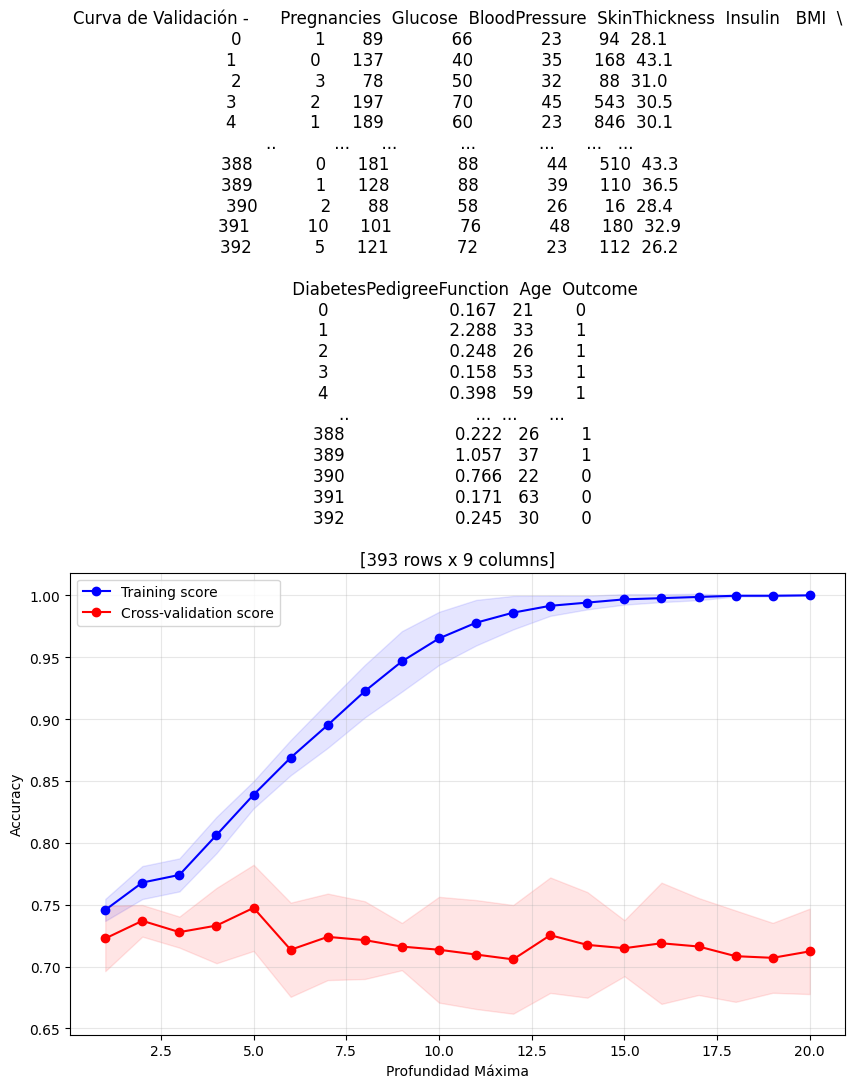

In [ ]:
param_range = range(1, 21)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(), df_mode.drop('Outcome', axis=1), df_mode['Outcome'], 
    param_name='max_depth',
    param_range=range(1, 21),
    cv=5  # 5-fold cross-validation
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, 'o-', color='blue', label='Training score')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')    
plt.plot(param_range, test_mean, 'o-', color='red', label='Cross-validation score')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, 
                     alpha=0.1, color='red')    
plt.xlabel('Profundidad Máxima')
plt.ylabel('Accuracy')
plt.title(f'Curva de Validación - {df_filtrado}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Modelado y Ajuste

In [33]:
dt_classifier_model = DecisionTreeClassifier(max_depth=5, random_state=24)
dt_classifier_model.fit(X_train_mode, y_train_mode)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

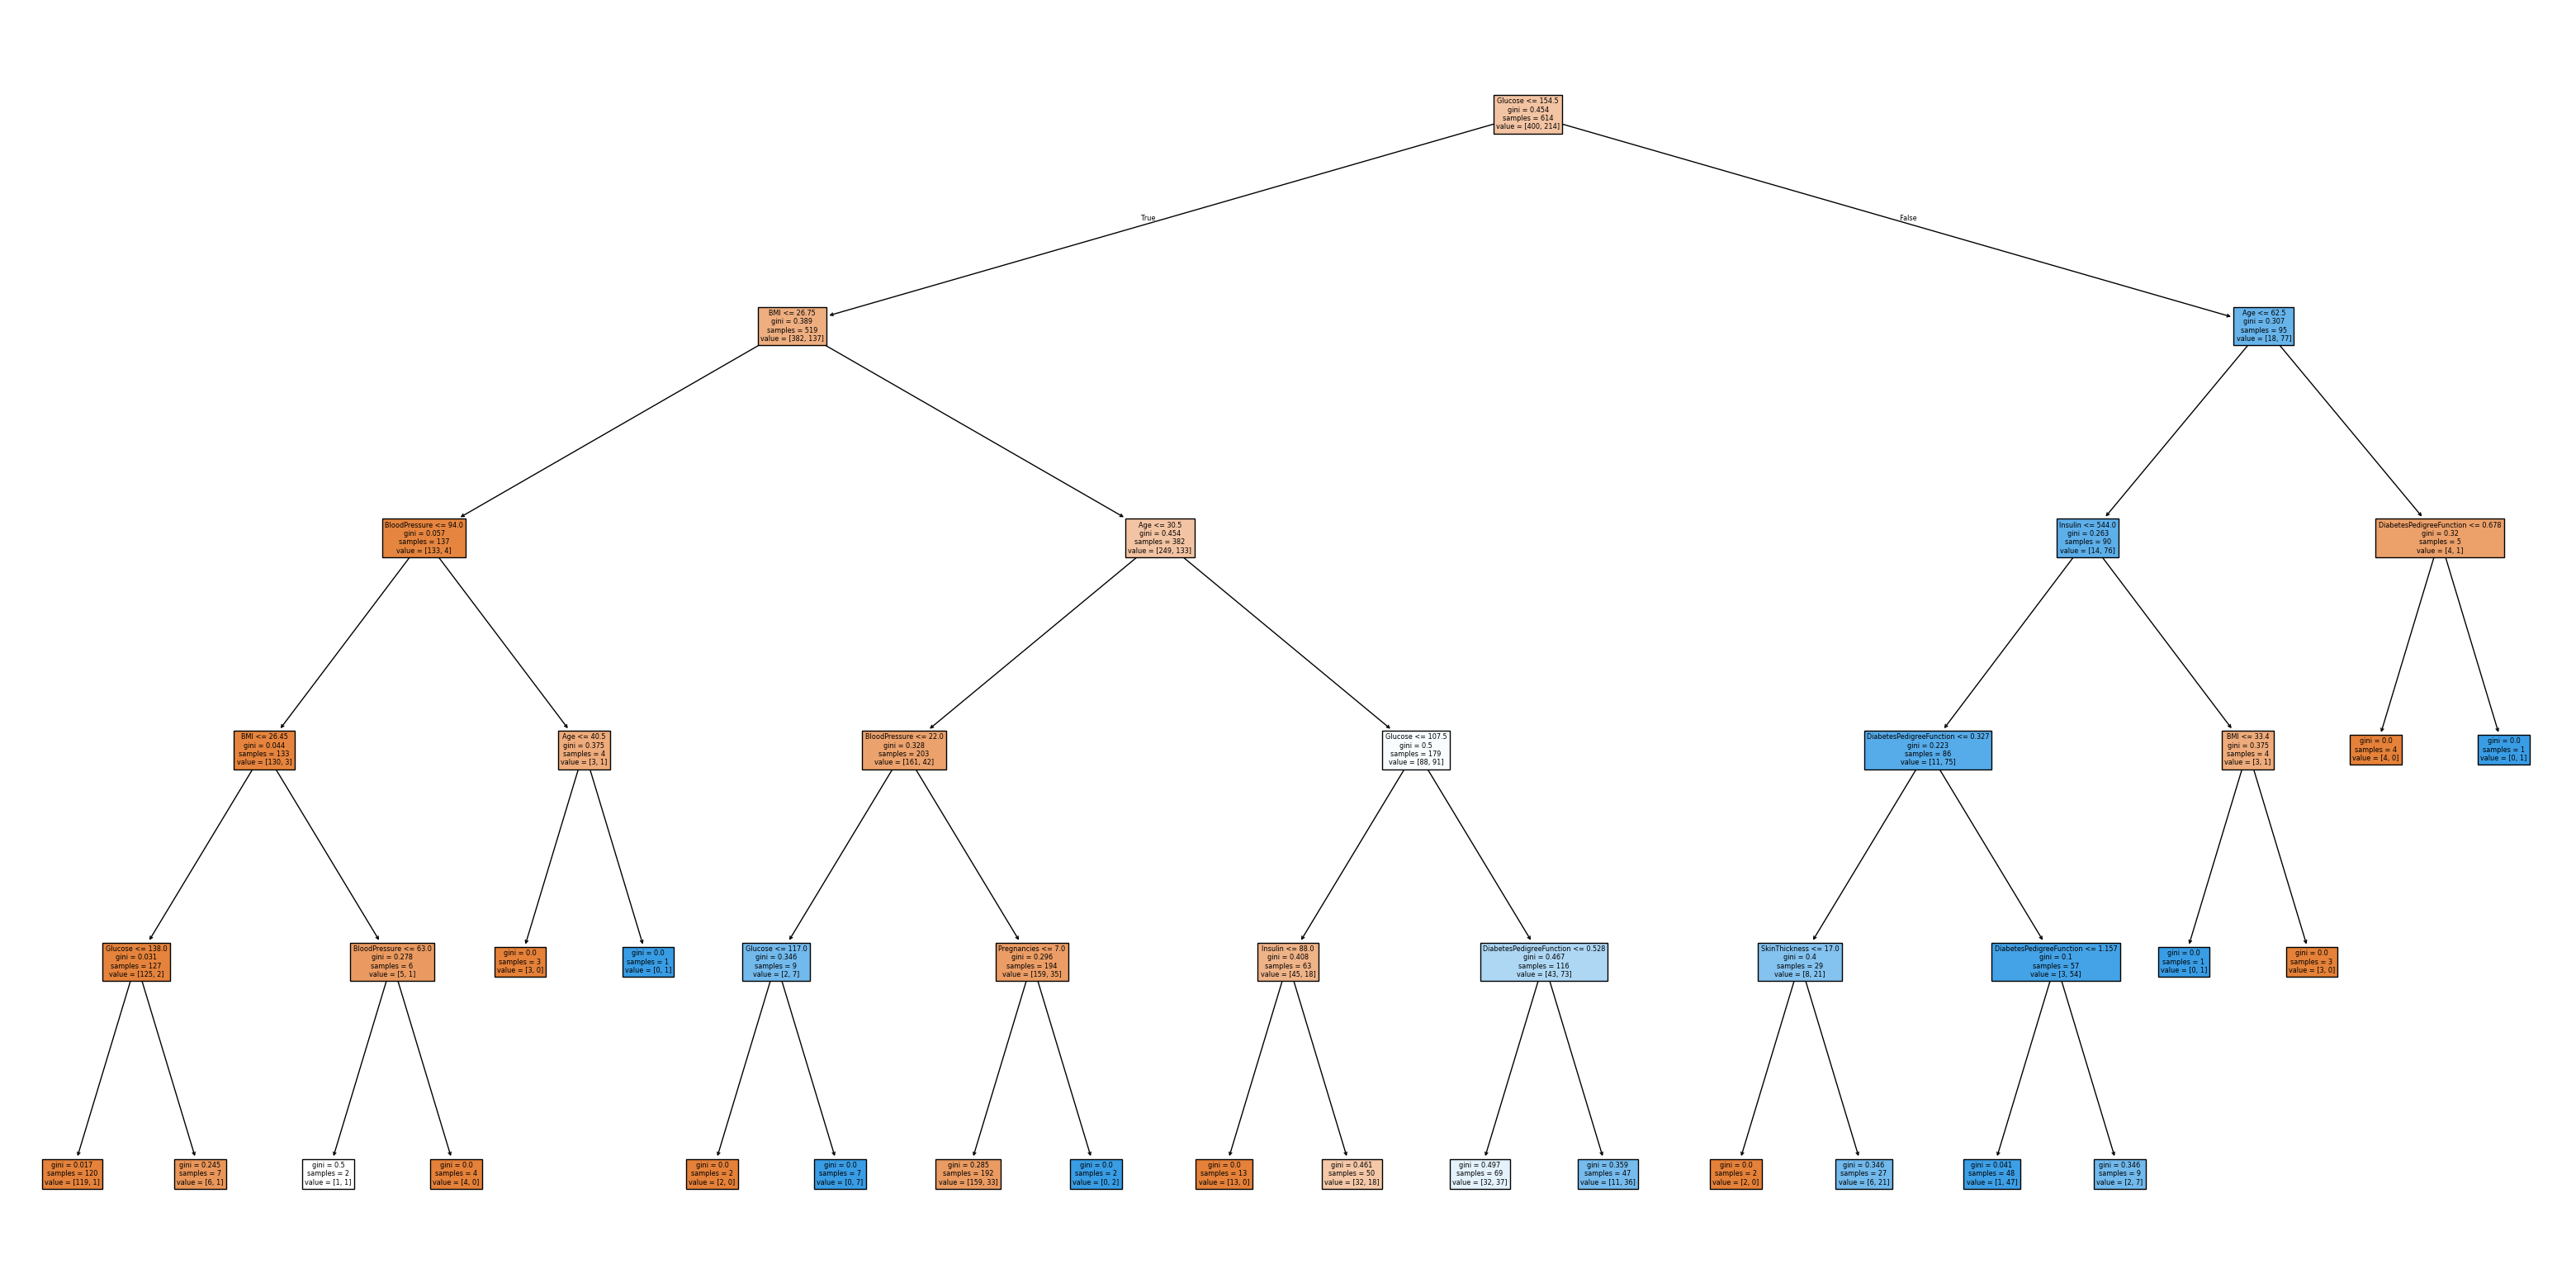

In [34]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train_mode.columns),
               filled=True)
plt.show()

#### Observamos que al tener más cantidad de datos el algoritmo se vuelve más complejo

#### Predicción 

In [35]:
y_pred_test_mode = dt_classifier_model.predict(X_test_mode)
y_pred_test_mode

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [36]:
y_pred_train_mode = dt_classifier_model.predict(X_train_mode)
y_pred_train_mode

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,

#### Métricas

In [37]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.827362,0.827362,0.827362
Test set,0.740260,0.740260,0.740260,0.740260


In [38]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.809502,0.810194,0.808832
Test set,0.740260,0.709653,0.714231,0.706296


In [39]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.827172,0.827000,0.827362
Test set,0.740260,0.737811,0.736404,0.740260


#### Observo que la tendencia general es que cuanto menos profundidad mejores métricas

## 3. Dataset con valores nulos remplazados por los k-nearest neighbors

In [23]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_kn.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.00000,232.600000,33.6,0.627,50,1
1,1,85,66,29.00000,184.800000,26.6,0.351,31,0
2,8,183,64,29.15342,155.548223,23.3,0.672,32,1
3,1,89,66,23.00000,94.000000,28.1,0.167,21,0
4,0,137,40,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.00000,180.000000,32.9,0.171,63,0
764,2,122,70,27.00000,155.400000,36.8,0.340,27,0
765,5,121,72,23.00000,112.000000,26.2,0.245,30,0
766,1,126,60,29.15342,155.548223,30.1,0.349,47,1


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [24]:
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis=1), 
                                                    df['Outcome'],
                                                    test_size=0.2,
                                                    random_state=24,
                                                    stratify=df['Outcome'])
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
712,10,129,62,36.00000,199.400000,41.2,0.441,38
626,0,125,68,29.15342,155.548223,24.7,0.206,21
157,1,109,56,21.00000,135.000000,25.2,0.833,23
401,6,137,61,29.15342,155.548223,24.2,0.151,55
355,9,165,88,29.15342,155.548223,30.4,0.302,49
...,...,...,...,...,...,...,...,...
381,0,105,68,22.00000,107.200000,20.0,0.236,22
324,2,112,75,32.00000,152.600000,35.7,0.148,21
68,1,95,66,13.00000,38.000000,19.6,0.334,25
704,4,110,76,20.00000,100.000000,28.4,0.118,27


#### Dibujamos la curva de validación para buscar la mejor profundidad del árbol

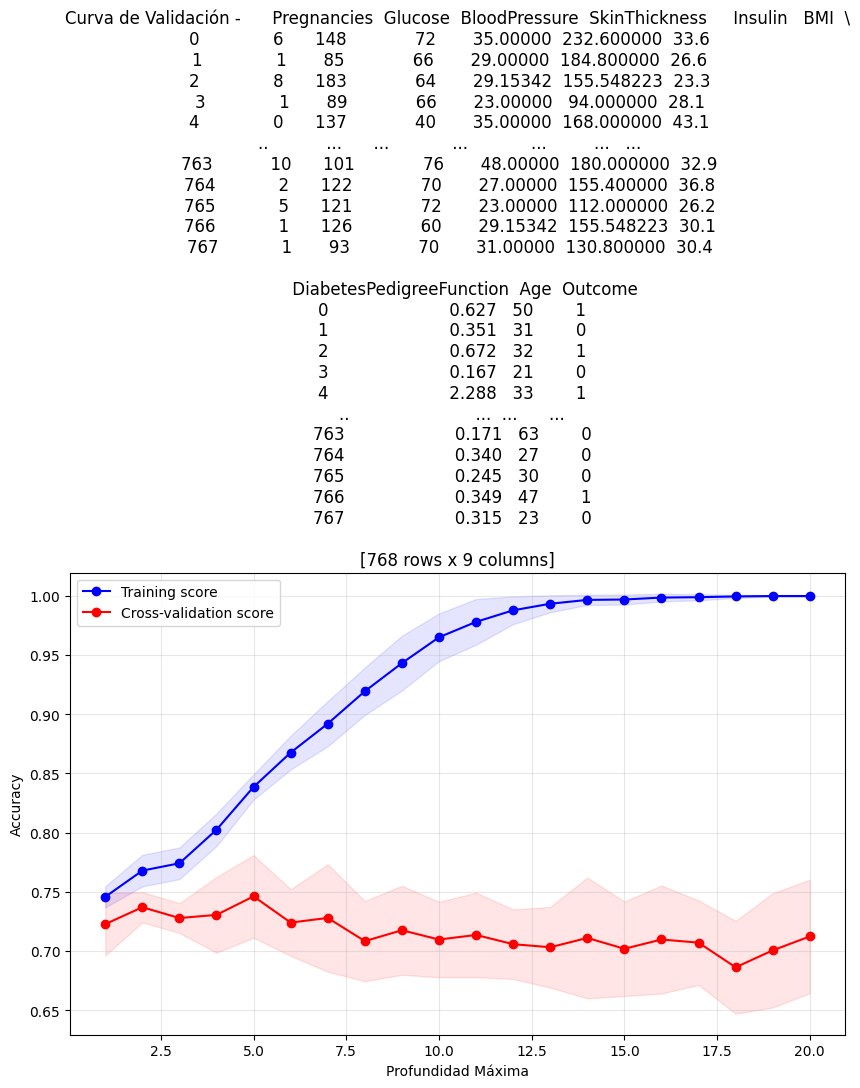

In [ ]:
param_range = range(1, 21)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(), df.drop('Outcome', axis=1), df['Outcome'], 
    param_name='max_depth',
    param_range=range(1, 21),
    cv=5  # 5-fold cross-validation
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, 'o-', color='blue', label='Training score')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')    
plt.plot(param_range, test_mean, 'o-', color='red', label='Cross-validation score')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, 
                     alpha=0.1, color='red')    
plt.xlabel('Profundidad Máxima')
plt.ylabel('Accuracy')
plt.title(f'Curva de Validación - {df}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Modelado y Ajuste

In [ ]:
dt_classifier_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5, min_samples_leaf=5, random_state=24) # Mejores parámetros hasta ahora
dt_classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

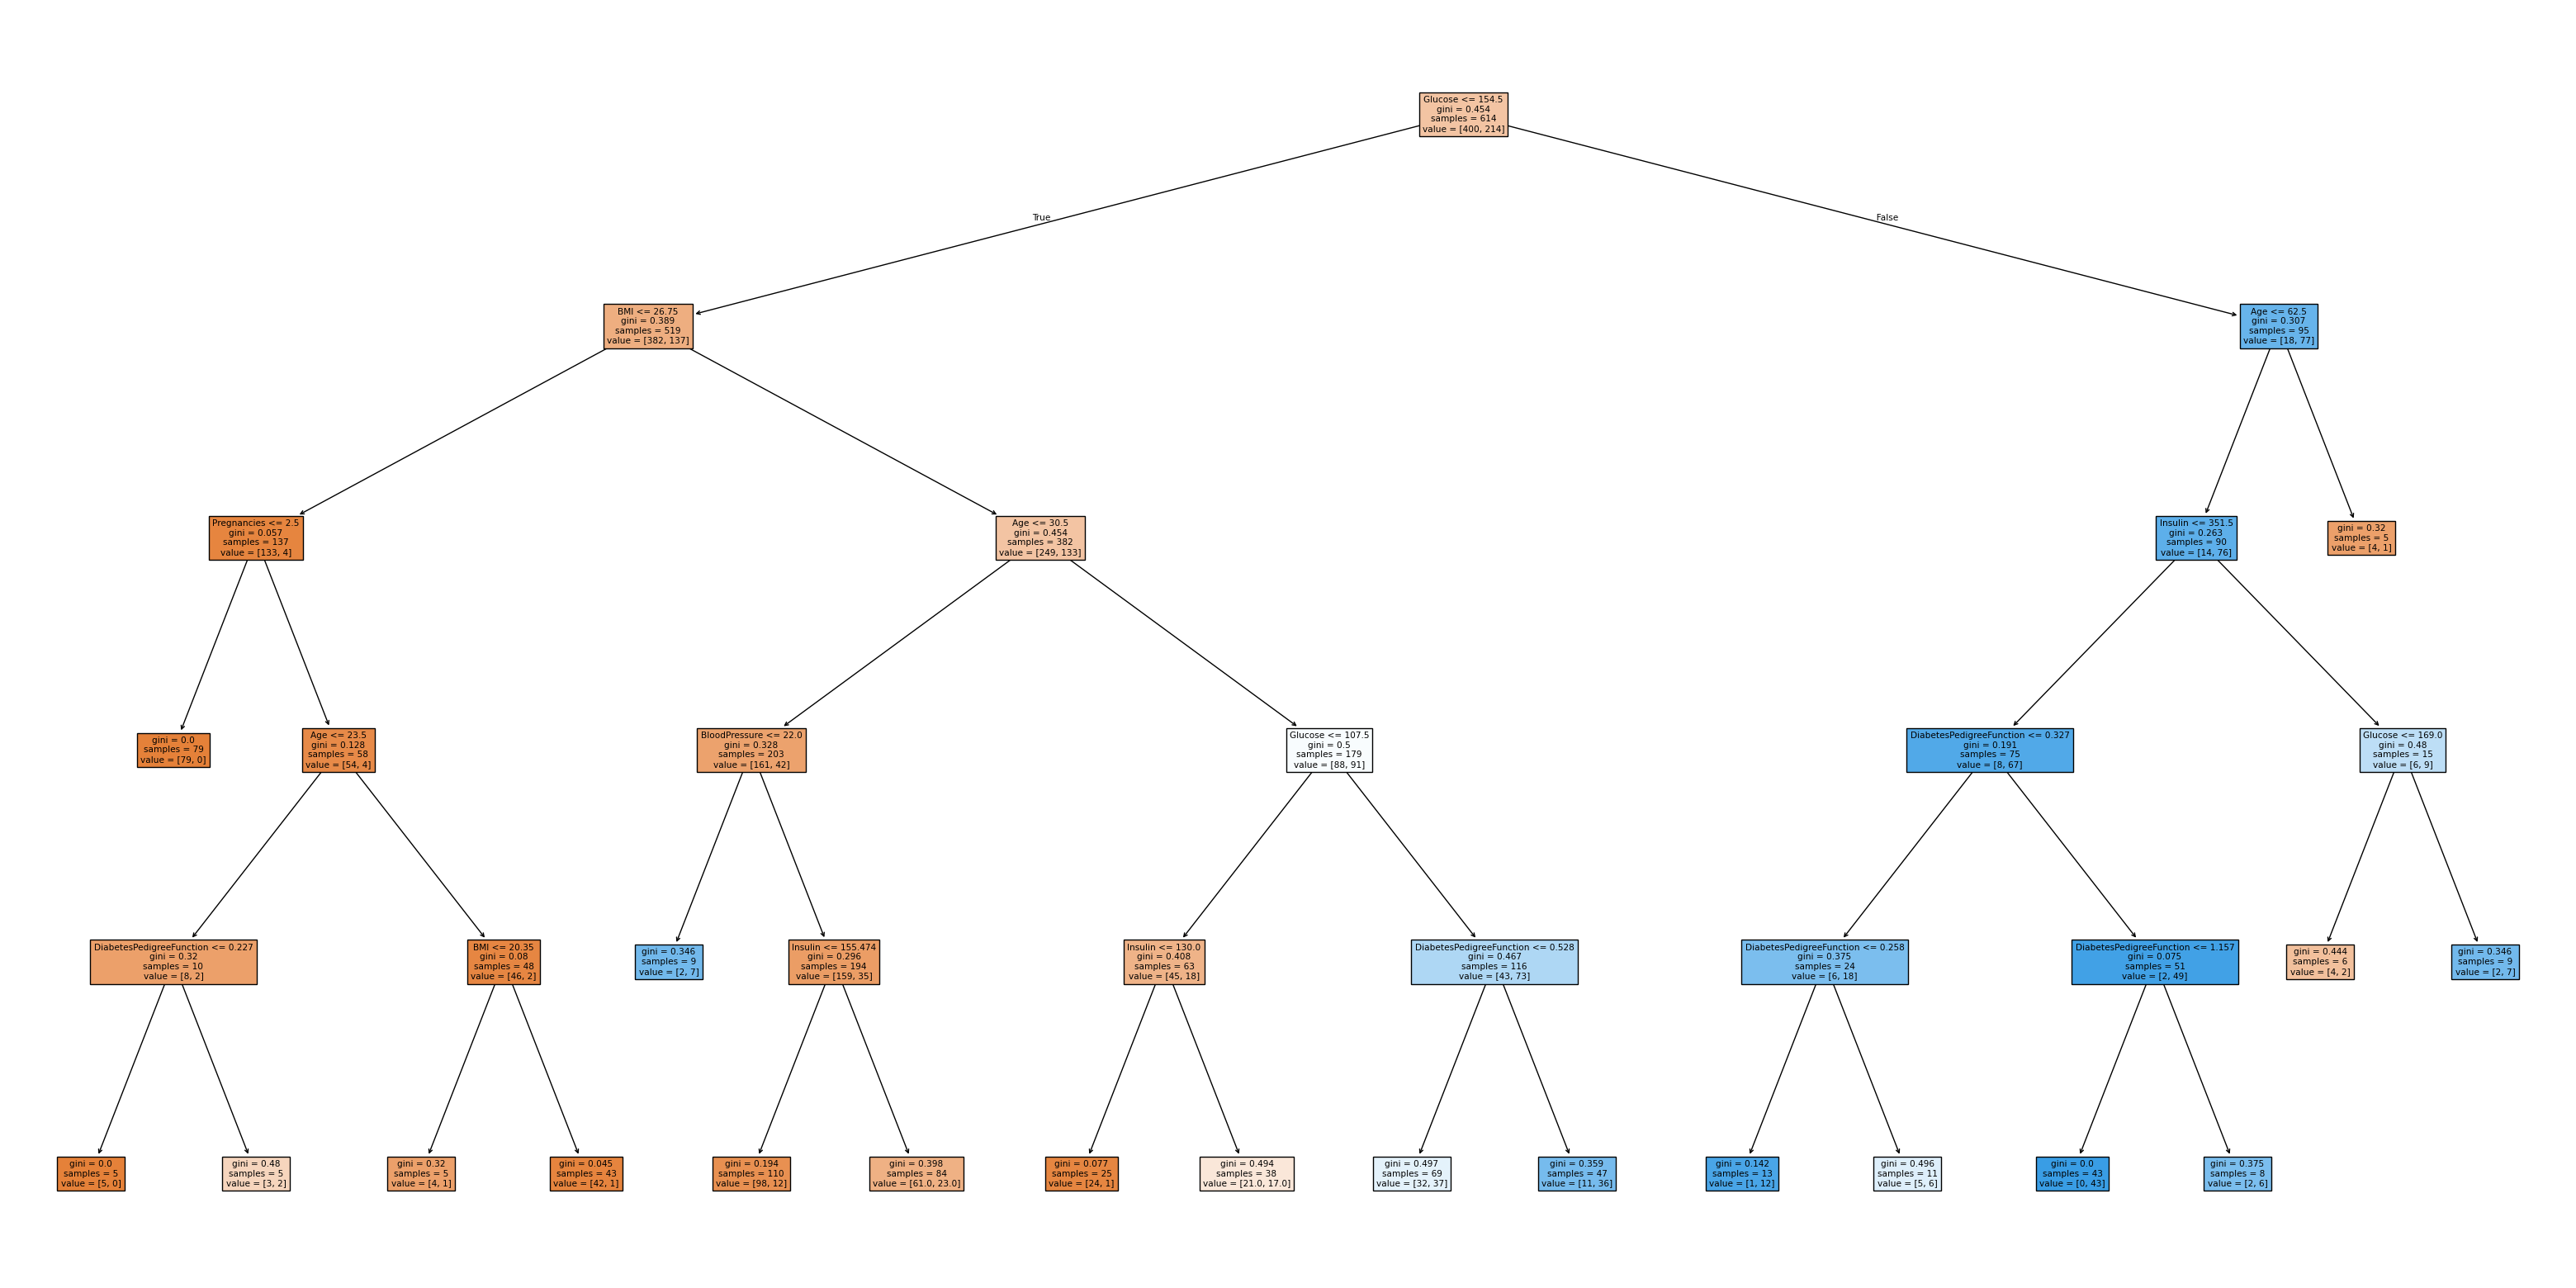

In [63]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train.columns),
               filled=True)
plt.show()

#### Observamos una complejidad parecida al anterior modelo, hay que analizar las métricas para comparar

#### Predicción 

In [64]:
y_pred_test = dt_classifier_model.predict(X_test)
y_pred_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [65]:
y_pred_train = dt_classifier_model.predict(X_train)
y_pred_train

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,

#### Métricas

In [66]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.812704,0.812704,0.812704,0.812704
Test set,0.746753,0.746753,0.746753,0.746753


In [67]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.812704,0.792638,0.794347,0.791063
Test set,0.746753,0.718227,0.721588,0.715556


In [68]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.812704,0.812178,0.811767,0.812704
Test set,0.746753,0.745007,0.743850,0.746753


## Conclusiones:

>- Después de varias pruebas, a profundidad máxima observamos que el modelo sufre overfitting (las métricas de train son perfectas)
>- Decido dibujar la curva de validación mediante `from sklearn.model_selection import validation_curve` para visualizar el punto de profundidad donde obtengo las mejores métricas para test y train
>- En todos los casos el dataset con datos truncados arroja mejores resultados en término de métricas, pero no sé si esto puede ser un indicador de que el modelo generaliza demasiado por la falta de datos, la lógica me dice que el modelo que más se ajusta a la realidad es el de sustitución por k-nearest.
>- Jugando con los parámetros del modelo podemos mejorar los resultados

## Buscamos los mejores parámetros con `GridSearchCV`

### Definición de parámetros y métricas

In [ ]:
param_grid = {'max_depth': [3, 5, 7, 10, 15, 20, None],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 2, 4, 8],
              'max_features': ['sqrt', 'log2', None]
    }
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
grid_search = GridSearchCV(estimator=dt_classifier_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring=scoring,
                           refit='accuracy',  # Métrica principal para seleccionar el mejor
                           n_jobs=-1,
                           verbose=1
    )


Fitting 5 folds for each of 336 candidates, totalling 1680 fits


,estimator,DecisionTreeC...ndom_state=24)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,"['accuracy', 'precision_weighted', ...]"
,n_jobs,-1
,refit,'accuracy'
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


#### Entrenamiento de la cuadrícula

In [ ]:
grid_search.fit(X_train, y_train)

#### Mejores parámetros

In [74]:
grid_search.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
grid_search.best_params_

{'max_depth': 7,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 20}

#### Reentrenamos al modelo con los nuevos parámetros:

In [ ]:
dt_classifier_model = DecisionTreeClassifier(max_depth=7, min_samples_split=20, min_samples_leaf=1, max_features='log2',  random_state=24)
dt_classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

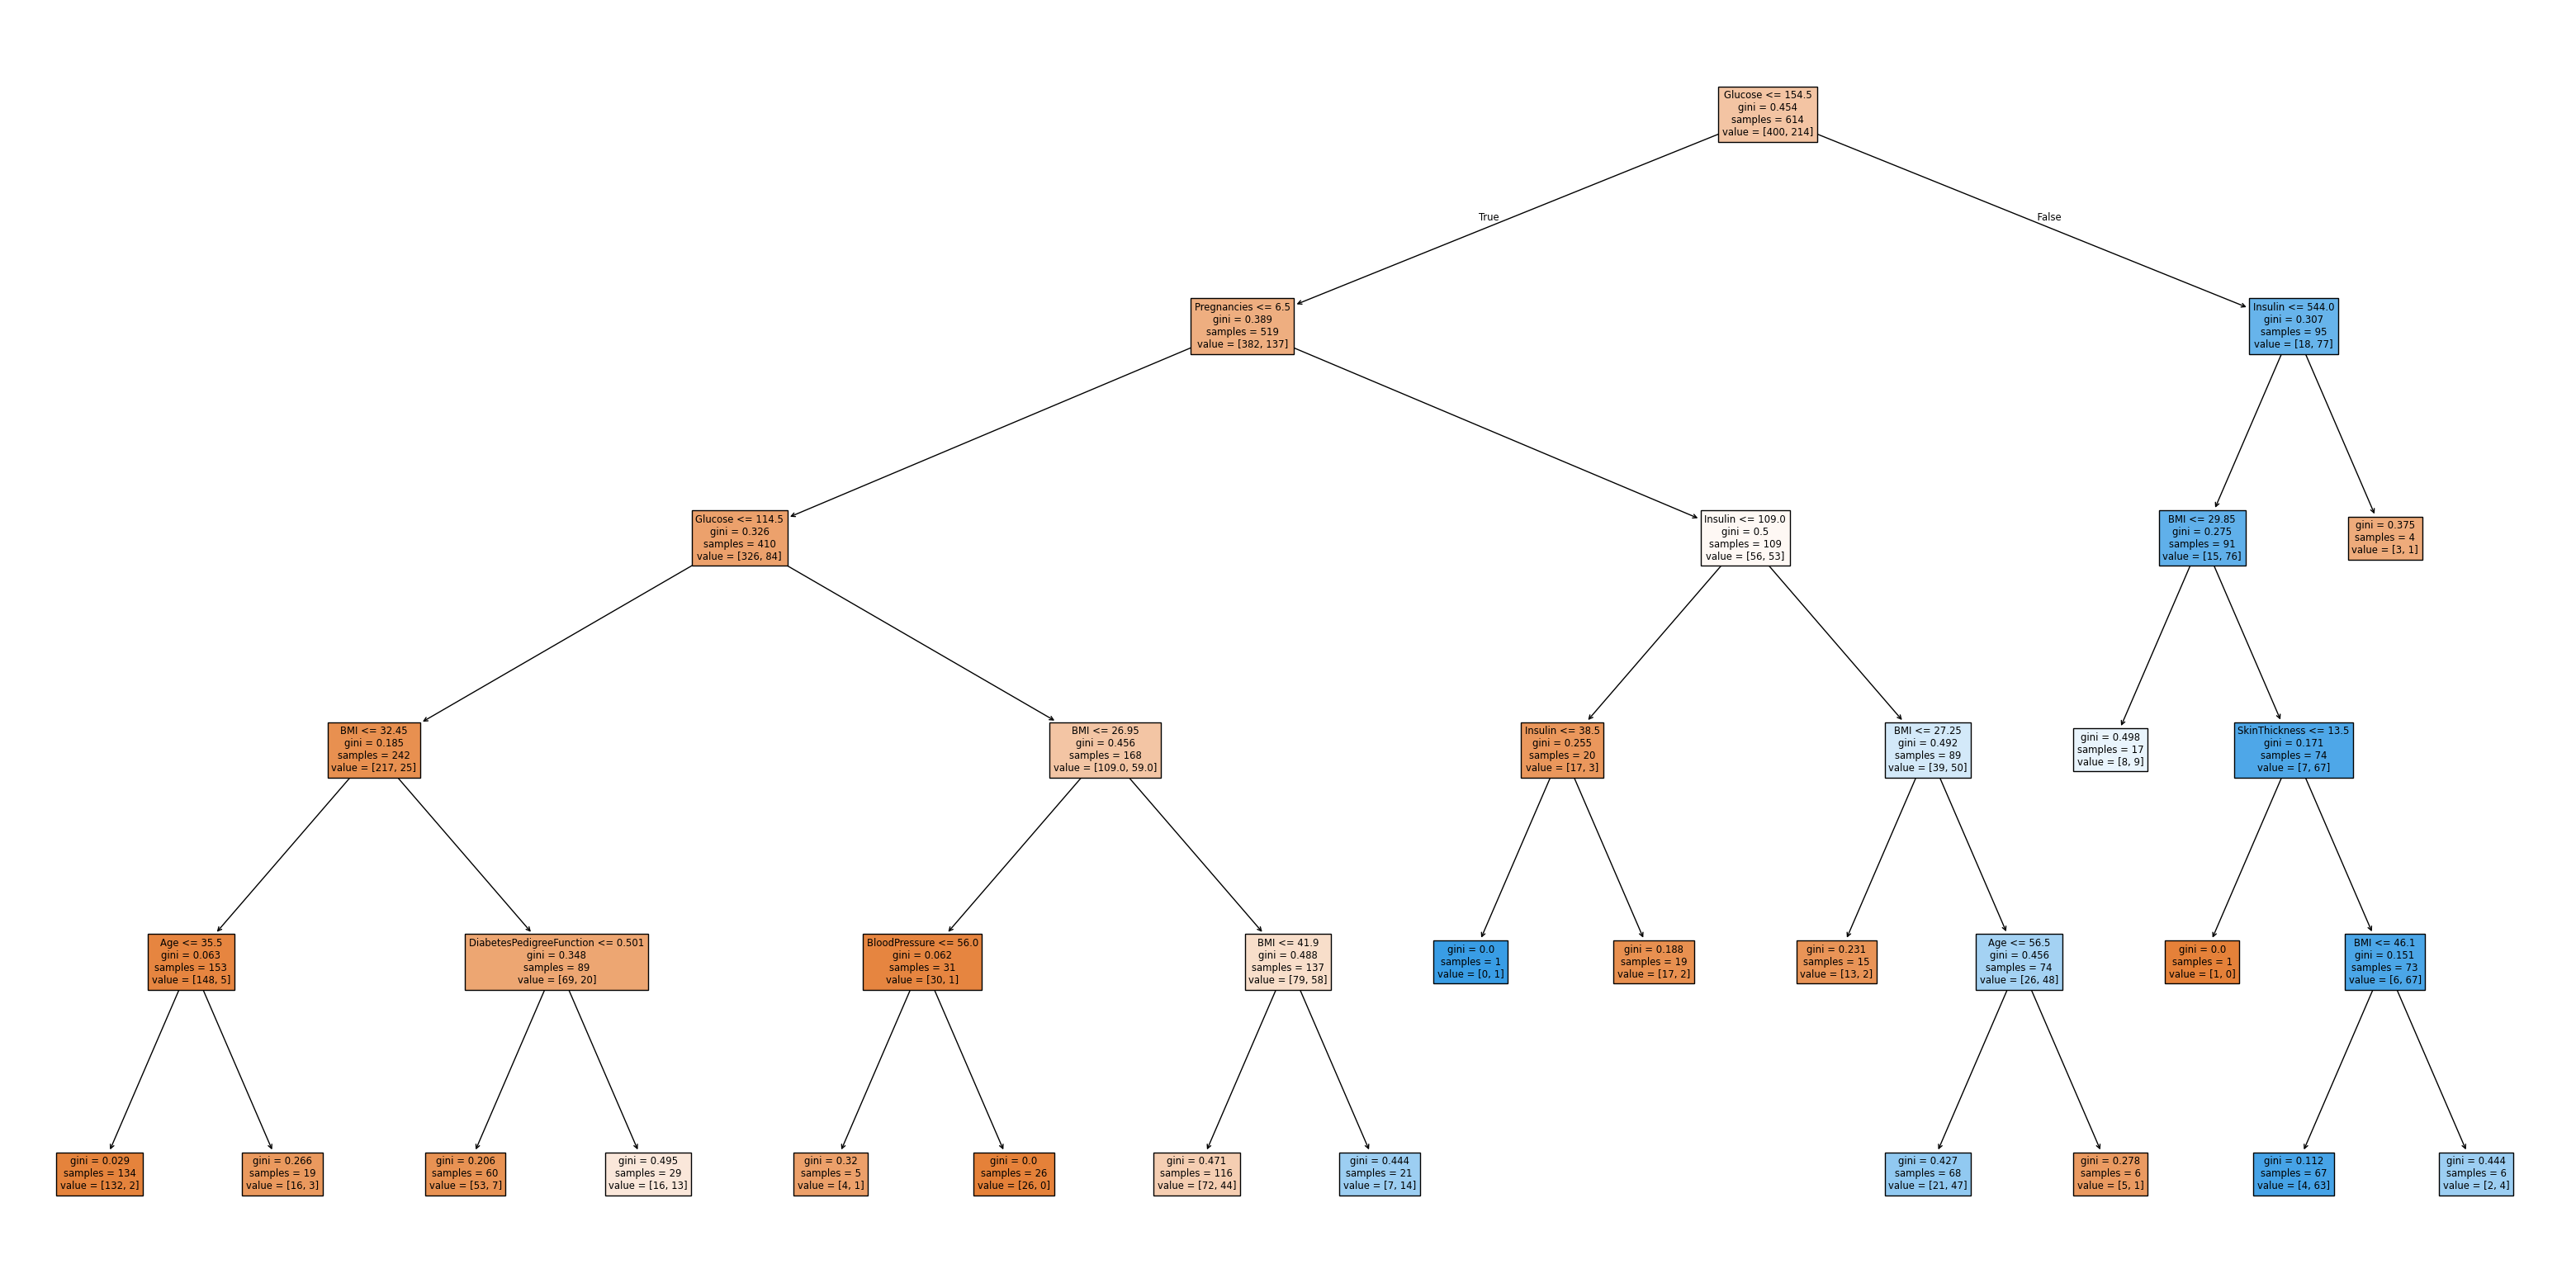

In [84]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train.columns),
               filled=True)
plt.show()

#### Predicción 

In [88]:
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0])

In [93]:
y_pred_train = best_model.predict(X_train)
y_pred_train

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,

#### Métricas

In [94]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.837134,0.837134,0.837134,0.837134
Test set,0.694805,0.694805,0.694805,0.694805


In [95]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.837134,0.805383,0.849838,0.786998
Test set,0.694805,0.633463,0.660545,0.628704


In [96]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.837134,0.829196,0.842215,0.837134
Test set,0.694805,0.678253,0.680245,0.694805


### La cuadrícula de hiperparametros no mejora el módelo, nos quedamos con el dataset con valores nulos sustituidos por los k-nearest con los valores "max_depth=5, min_samples_split=5, min_samples_leaf=5"